## 1. Feature mapping

In [1]:
from logging import info

import pandas as pd
df = pd.read_csv("features.csv")
print(df.shape[0]) #rows
print(df.shape[1]) #columns
for col in df.columns:
    print(col)

1129
83
LSOA21CD
LSOA21NM
LSOA21NMW
RUC21CD
RUC21NM
Urban_rura
Shape_Leng
Shape__Are
Shape__Len
MSOA21CD
MSOA21NM
VOA_hereditaments_2023
VOA_total_RV_2023
VOA_median_RV_2023
VOA_total_RV_million_2023
VOA_median_RV_thousand_2023
VOA_hereditaments_2026
VOA_total_RV_2026
VOA_median_RV_2026
VOA_total_RV_million_2026
VOA_median_RV_thousand_2026
VOA_total_RV_pct_change
Mid-2024 population
Apprenticeship %
Level 1 and entry level qualifications: 1 to 4 GCSEs grade A* to C, Any GCSEs at other grades, O levels or CSEs (any grades), 1 AS level, NVQ level 1, Foundation GNVQ, Basic or Essential Skills %
Level 2 qualifications: 5 or more GCSEs (A* to C or 9 to 4), O levels (passes), CSEs (grade 1), School Certification, 1 A level, 2 to 3 AS levels, VCEs, Intermediate or Higher Diploma, Welsh Baccalaureate Intermediate Diploma, NVQ level 2, Intermediate GNVQ, City and Guilds Craft, BTEC First or General Diploma, RSA Diploma %
Level 3 qualifications: 2 or more A levels or VCEs, 4 or more AS levels, H

In [2]:
selected_cols = [
    #target
    "LSOA GVA Estimates (millions)",
    #policy
    "Urban_rura", "RUC21NM",
    #business size structure
    "LU_pct_micro_2025_msoa", "LU_pct_small_2025_msoa",
    "LU_pct_medium_2025_msoa", "LU_pct_large_2025_msoa",
    "enterprises_per_1k_residents_2025", "total_enterprises_2025_msoa",
    #economic resilience
    "turnover_diversity_1-HHI_2025_msoa", "LU_diversity_1-HHI_2025",
    "share_enterprises_creative_2025_msoa", "share_enterprises_foundational_2025_msoa",
    "share_enterprises_green_aligned_2025_msoa", "share_enterprises_industrial_2025_msoa",
    "share_enterprises_kibs_2025_msoa", "share_enterprises_anchor_2025_msoa",
    "share_enterprises_public_2025_msoa", "share_enterprises_private_2025_msoa",
    #employment
    "employment_rate_per_pop", "full_to_part_ratio", "total_employees",
    #controls, education & skills
    "Apprenticeship %",
    "Level 1 and entry level qualifications: 1 to 4 GCSEs grade A* to C, Any GCSEs at other grades, O levels or CSEs (any grades), 1 AS level, NVQ level 1, Foundation GNVQ, Basic or Essential Skills %",
    "Level 2 qualifications: 5 or more GCSEs (A* to C or 9 to 4), O levels (passes), CSEs (grade 1), School Certification, 1 A level, 2 to 3 AS levels, VCEs, Intermediate or Higher Diploma, Welsh Baccalaureate Intermediate Diploma, NVQ level 2, Intermediate GNVQ, City and Guilds Craft, BTEC First or General Diploma, RSA Diploma %",
    "Level 3 qualifications: 2 or more A levels or VCEs, 4 or more AS levels, Higher School Certificate, Progression or Advanced Diploma, Welsh Baccalaureate Advance Diploma, NVQ level 3; Advanced GNVQ, City and Guilds Advanced Craft, ONC, OND, BTEC National, RSA Advanced Diploma %",
    "Level 4 qualifications or above: degree (BA, BSc), higher degree (MA, PhD, PGCE), NVQ level 4 to 5, HNC, HND, RSA Higher Diploma, BTEC Higher level, professional qualifications (for example, teaching, nursing, accountancy) %",
    "No qualifications %",
    "Other: vocational or work-related qualifications, other qualifications achieved in England or Wales, qualifications achieved outside England or Wales (equivalent not stated or unknown) %",
    #controls, deprivation
    "IMD_decile", "Income_decile", "Employment_decile",
    "Education_decile", "AdultSkills_decile",
    #controls, digital connectivity
    "Percentage of connections receiving less than 10Mbit/s broadband",
    "Average download speed (Mbit/s)",
    "Percentage of homes unable to receive at least 30Mbit/s broadband",
    #controls, transport access
    "bus_stop_density", "dist_to_primary_m",
    #controls, population
    "Mid-2024 population", "Working_Age_Pop", "Pct_Working_Age",
    #ids
    "LSOA21CD", "LSOA21NM", "MSOA21CD", "MSOA21NM", "area_km2",
    #raw counts for feature engineering
    "LU_micro_2025_msoa", "LU_small_2025_msoa", "LU_medium_2025_msoa",
    "LU_large_2025_msoa", "LU_total_2025_msoa",
    "full_time_employees", "part_time_employees",
]
features_selected = df[selected_cols]
print(features_selected.shape)
features_selected.to_csv("1-features_selected.csv", index=False)

(1129, 54)


## 2. Inspect data overview

In [3]:
df = pd.read_csv("1-features_selected.csv")
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False)) #checking missing value

LSOA GVA Estimates (millions)    105
full_to_part_ratio                 4
dtype: int64


In [4]:
print(df.dtypes.value_counts()) #checking data type

float64    32
int64      16
object      6
Name: count, dtype: int64


In [5]:
print("Duplicate LSOA codes:", df["LSOA21CD"].duplicated().sum()) #checking duplicate LSOA code

Duplicate LSOA codes: 4


In [6]:
print(df.describe())  #checking count, mean, std, min, 25%, 50%, 75%, max

       LSOA GVA Estimates (millions)  LU_pct_micro_2025_msoa  \
count                    1024.000000             1129.000000   
mean                       84.864619                0.857709   
std                       264.108469                0.064586   
min                         4.977000                0.645985   
25%                        13.362250                0.822785   
50%                        24.274000                0.868263   
75%                        57.575000                0.905660   
max                      4407.307000                0.969697   

       LU_pct_small_2025_msoa  LU_pct_medium_2025_msoa  \
count             1129.000000              1129.000000   
mean                 0.112123                 0.026563   
std                  0.048992                 0.018015   
min                  0.015385                 0.000000   
25%                  0.075472                 0.013699   
50%                  0.107784                 0.023810   
75%              

## 3. Handle duplicate rows and missing values

In [7]:
df = df.drop_duplicates(subset="LSOA21CD")
df = df.dropna(subset=["LSOA GVA Estimates (millions)"])
df["full_to_part_ratio"] = df["full_to_part_ratio"].fillna(0)
print(df.shape)
print("Remaining missing values:", df.isna().sum().sum())
df.to_csv("2-features_clean.csv", index=False)

(1024, 54)
Remaining missing values: 0


## 4. Handle outliers

In [8]:
df = pd.read_csv("2-features_clean.csv")
print("Negative GVA:", (df["LSOA GVA Estimates (millions)"] < 0).sum())
numeric_cols = df.select_dtypes(include="number").columns
for c in numeric_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df[c] < low) | (df[c] > high)).sum()
    if n > 0:
        print(f"{c}: {n}")

Negative GVA: 0
LSOA GVA Estimates (millions): 133
LU_pct_micro_2025_msoa: 12
LU_pct_small_2025_msoa: 2
LU_pct_medium_2025_msoa: 22
LU_pct_large_2025_msoa: 34
enterprises_per_1k_residents_2025: 42
total_enterprises_2025_msoa: 28
LU_diversity_1-HHI_2025: 9
share_enterprises_creative_2025_msoa: 48
share_enterprises_green_aligned_2025_msoa: 34
share_enterprises_industrial_2025_msoa: 41
share_enterprises_kibs_2025_msoa: 13
share_enterprises_anchor_2025_msoa: 24
share_enterprises_public_2025_msoa: 71
share_enterprises_private_2025_msoa: 71
employment_rate_per_pop: 129
full_to_part_ratio: 39
total_employees: 133
Apprenticeship %: 23
Level 1 and entry level qualifications: 1 to 4 GCSEs grade A* to C, Any GCSEs at other grades, O levels or CSEs (any grades), 1 AS level, NVQ level 1, Foundation GNVQ, Basic or Essential Skills %: 14
Level 2 qualifications: 5 or more GCSEs (A* to C or 9 to 4), O levels (passes), CSEs (grade 1), School Certification, 1 A level, 2 to 3 AS levels, VCEs, Intermediate

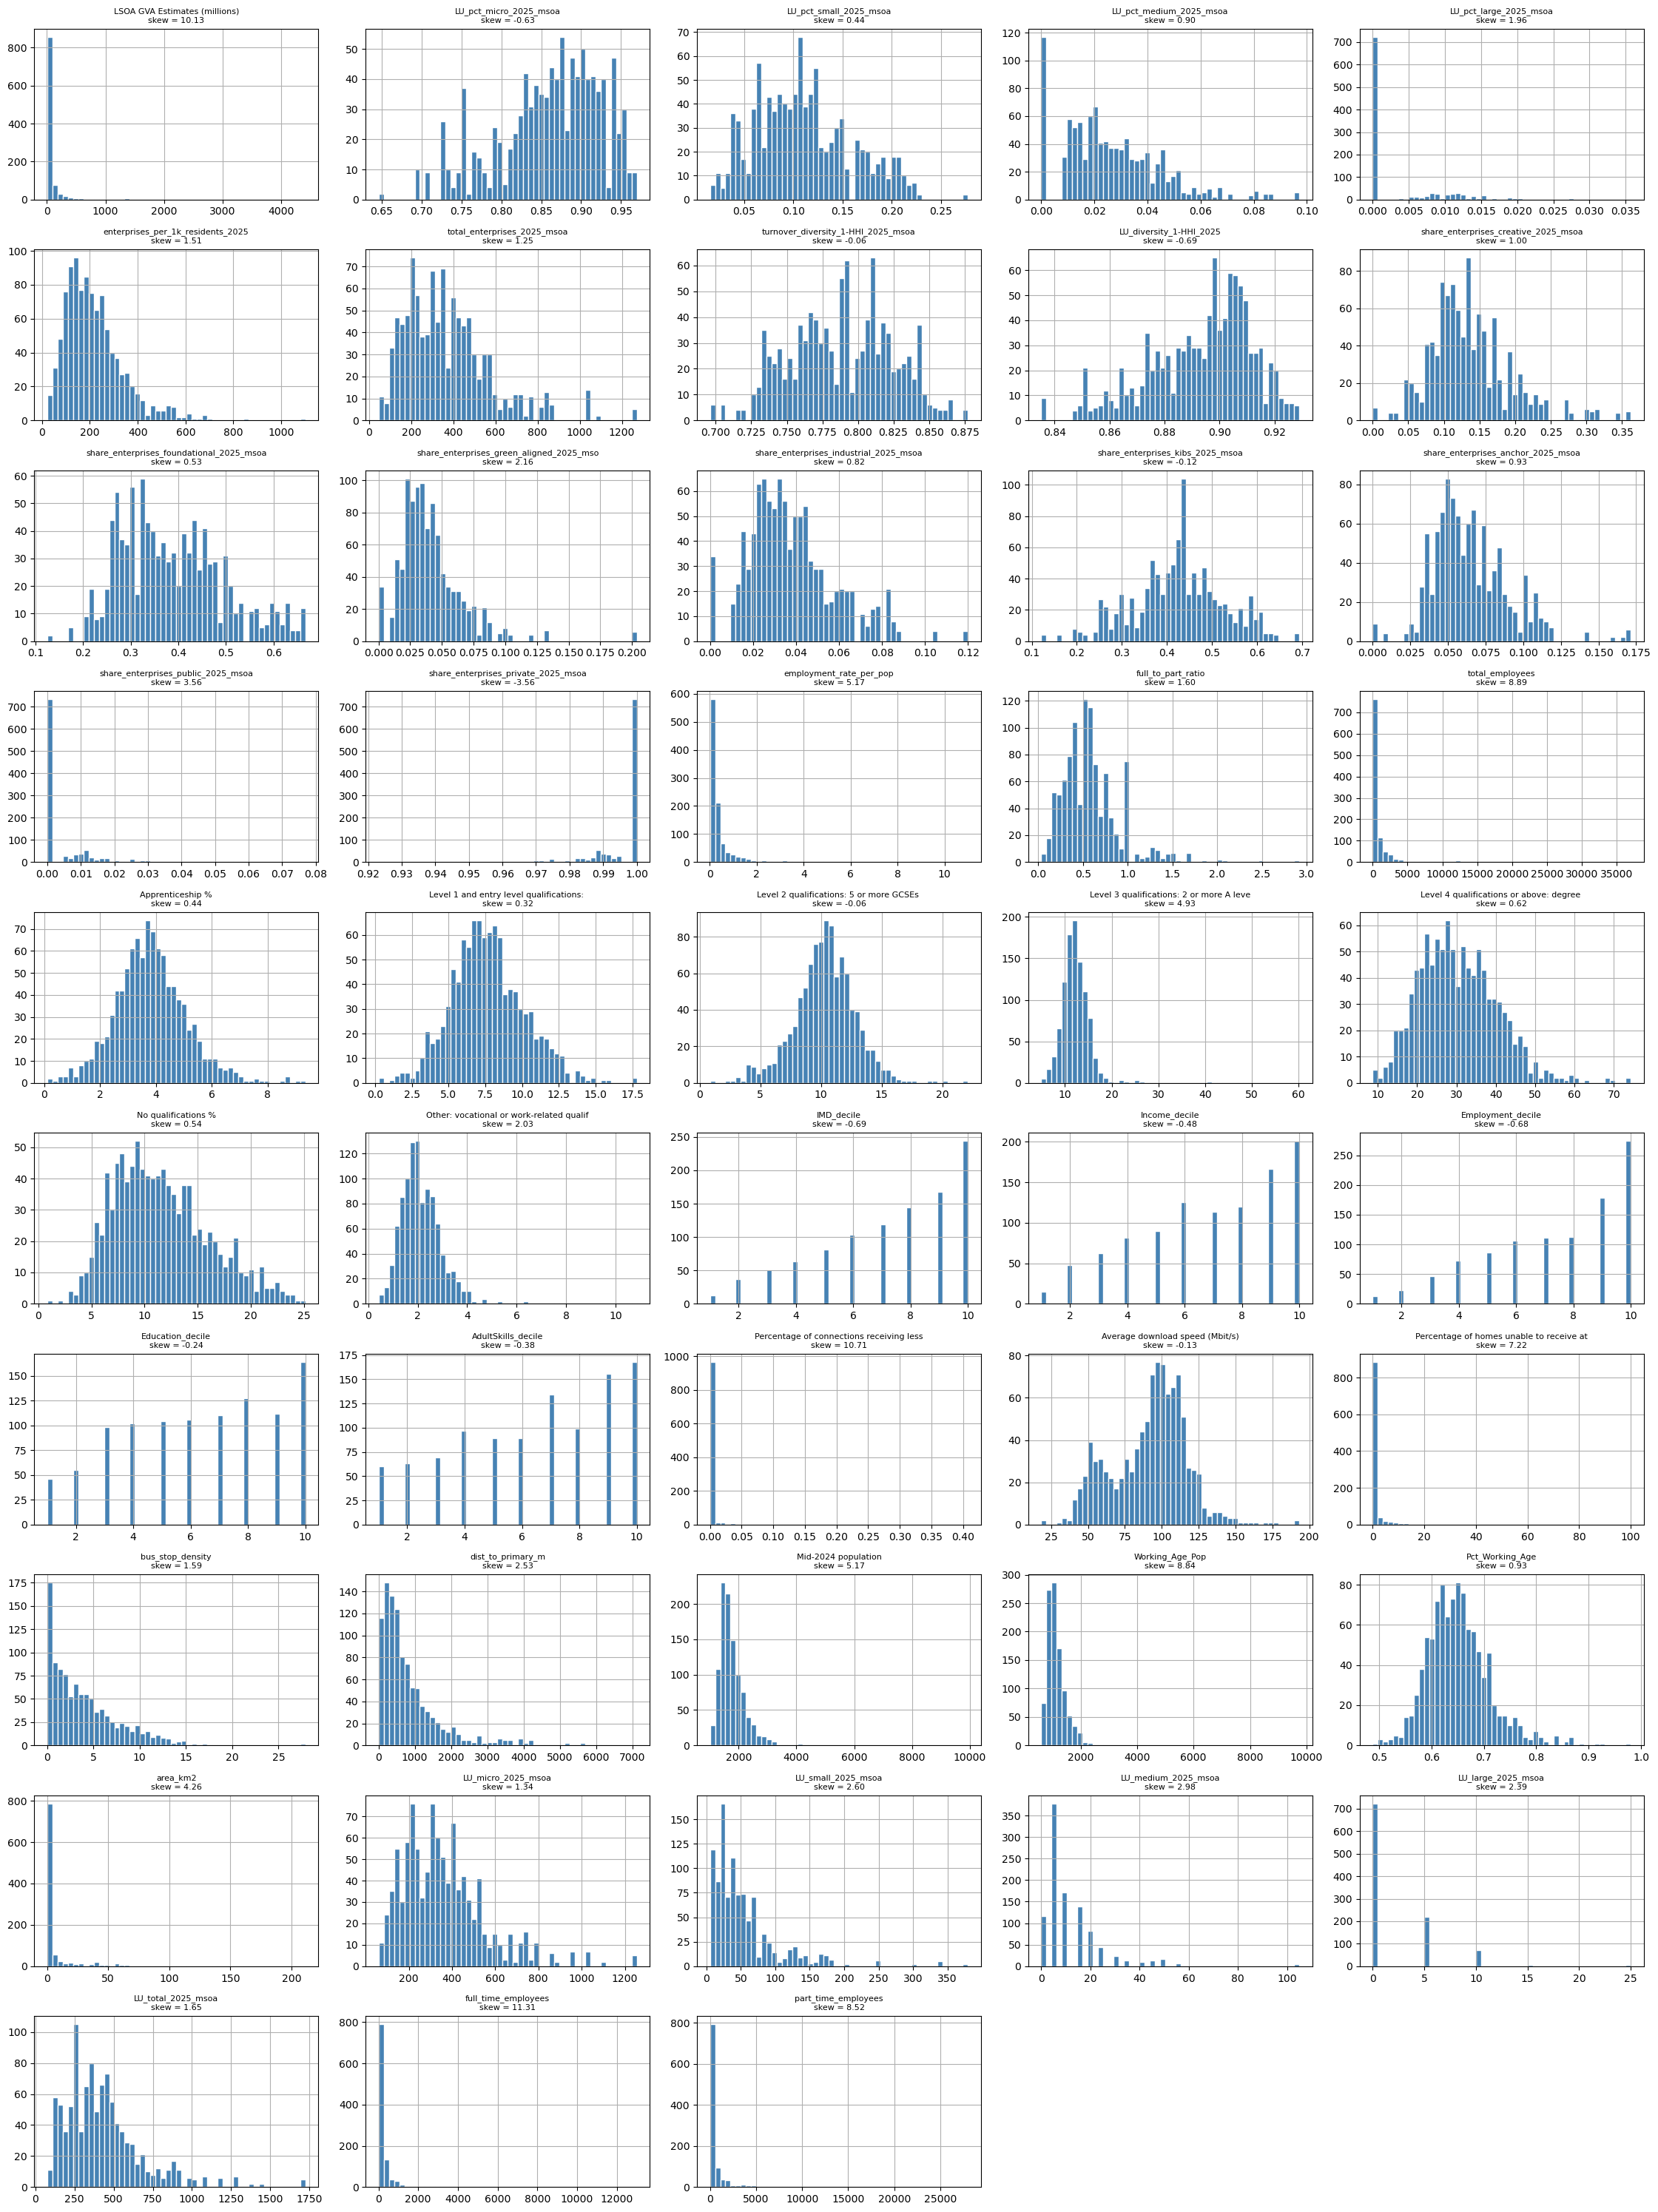

In [9]:
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include="number").columns
n = len(numeric_cols)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 3))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"{col[:40]}\nskew = {df[col].skew():.2f}", fontsize=8)

for ax in axes.flat[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("dist_all.png", dpi=120)
plt.show()

In [10]:
skew = df[numeric_cols].skew()
skewed_cols = skew[skew > 1].index.tolist()
len(skewed_cols)

25

In [11]:
print(skew[skew > 1].sort_values(ascending=False))

full_time_employees                                                                                                                                                                                                                                                                      11.305748
Percentage of connections receiving less than 10Mbit/s broadband                                                                                                                                                                                                                         10.707514
LSOA GVA Estimates (millions)                                                                                                                                                                                                                                                            10.133844
total_employees                                                                                                                

In [12]:
# log, to solve skewed variables
import numpy as np
log_cols = [
    "full_time_employees",
    "total_employees",
    "part_time_employees",
    "Working_Age_Pop",
    "Mid-2024 population",
    "area_km2",
    "dist_to_primary_m",
    "bus_stop_density",
    "enterprises_per_1k_residents_2025",
    "total_enterprises_2025_msoa",
    "LU_micro_2025_msoa",
    "LU_small_2025_msoa",
    "LU_medium_2025_msoa",
    "LU_large_2025_msoa",
    "LU_total_2025_msoa",
    "LSOA GVA Estimates (millions)",
]
for col in log_cols:
    df[f"log_{col}"] = np.log1p(df[col])
df.to_csv("3-features_transformed.csv", index=False)

In [13]:
df = pd.read_csv("3-features_transformed.csv")
for c in log_cols:
    before = df[c].skew()
    after = df[f"log_{c}"].skew()
    print(f"{c[:35]:37s} {before:7.2f} -> {after:7.2f}")

full_time_employees                     11.31 ->    0.08
total_employees                          8.89 ->    0.39
part_time_employees                      8.52 ->    0.54
Working_Age_Pop                          8.84 ->    1.10
Mid-2024 population                      5.17 ->    1.03
area_km2                                 4.26 ->    1.57
dist_to_primary_m                        2.53 ->   -0.83
bus_stop_density                         1.59 ->   -0.03
enterprises_per_1k_residents_2025        1.51 ->   -0.38
total_enterprises_2025_msoa              1.25 ->   -0.37
LU_micro_2025_msoa                       1.34 ->   -0.25
LU_small_2025_msoa                       2.60 ->   -0.12
LU_medium_2025_msoa                      2.98 ->   -0.61
LU_large_2025_msoa                       2.39 ->    1.05
LU_total_2025_msoa                       1.65 ->   -0.16
LSOA GVA Estimates (millions)           10.13 ->    1.15


## 5. Feature Engineering

In [14]:
#total GVA scales with size, per-capita isolates true economic efficiency for fair area comparison
df["gva_per_capita"] = df["LSOA GVA Estimates (millions)"] / df["Mid-2024 population"]
#identity and the target measures output efficiency rather than size. (total_employees has no zeros.)
df["gva_per_worker"] = df["LSOA GVA Estimates (millions)"] * 1e6 / df["total_employees"]
df["log_gva_per_worker"] = np.log1p(df["gva_per_worker"])
#captures average firm scale, adding depth to the business size structure node
df["employees_per_enterprise"] = df["total_employees"] / df["total_enterprises_2025_msoa"]
#bounded 0-1 measure of job quality, more stable than full_to_part_ratio which breaks when part-time is zero
df["full_time_share"] = df["full_time_employees"] / (
    df["full_time_employees"] + df["part_time_employees"]
)
df.to_csv("4-features_engineered.csv", index=False)
print(df[["gva_per_capita", "gva_per_worker", "employees_per_enterprise", "full_time_share"]].describe())

       gva_per_capita  gva_per_worker  employees_per_enterprise  \
count     1024.000000    1.024000e+03               1024.000000   
mean         0.046413    1.202942e+05                  2.459343   
std          0.141589    2.859349e+05                  5.055545   
min          0.003372    7.908417e+03                  0.035294   
25%          0.008226    6.071967e+04                  0.520833   
50%          0.014202    7.934523e+04                  1.017072   
75%          0.032367    1.139373e+05                  2.124170   
max          2.630722    6.185720e+06                 68.750000   

       full_time_share  
count      1024.000000  
mean          0.347117  
std           0.116014  
min           0.032258  
25%           0.272727  
50%           0.333333  
75%           0.428571  
max           0.744681  


## 6. Standardise features

In [15]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("4-features_engineered.csv")
for col in ["gva_per_capita", "employees_per_enterprise"]:
    if col in df.columns and f"log_{col}" not in df.columns:
        df[f"log_{col}"] = np.log1p(df[col])

skill_cols = [c for c in df.columns if "qualification" in c.lower() or c.startswith("Apprenticeship")]

candidate_cols = [
    "log_full_time_employees", "log_total_employees", "log_part_time_employees",
    "log_Working_Age_Pop", "log_Mid-2024 population", "log_area_km2",
    "log_dist_to_primary_m", "log_bus_stop_density",
    "log_enterprises_per_1k_residents_2025", "log_total_enterprises_2025_msoa",
    "log_LU_micro_2025_msoa", "log_LU_small_2025_msoa", "log_LU_medium_2025_msoa",
    "log_LU_large_2025_msoa", "log_LU_total_2025_msoa",
    "log_employees_per_enterprise", "full_time_share",
    "LU_pct_micro_2025_msoa", "LU_pct_small_2025_msoa",
    "LU_pct_medium_2025_msoa", "LU_pct_large_2025_msoa",
    "turnover_diversity_1-HHI_2025_msoa", "LU_diversity_1-HHI_2025",
    "share_enterprises_creative_2025_msoa", "share_enterprises_foundational_2025_msoa",
    "share_enterprises_green_aligned_2025_msoa", "share_enterprises_industrial_2025_msoa",
    "share_enterprises_kibs_2025_msoa", "share_enterprises_anchor_2025_msoa",
    "share_enterprises_public_2025_msoa", "share_enterprises_private_2025_msoa",
    "employment_rate_per_pop", "full_to_part_ratio", "Pct_Working_Age",
    "Percentage of connections receiving less than 10Mbit/s broadband",
    "Average download speed (Mbit/s)",
    "Percentage of homes unable to receive at least 30Mbit/s broadband",
    "IMD_decile", "Income_decile", "Employment_decile",
    "Education_decile", "AdultSkills_decile",
] + skill_cols

scale_cols = [c for c in candidate_cols if c in df.columns]
missing = [c for c in candidate_cols if c not in df.columns]
if missing:
    print("Skipped (not in file):", missing)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["MSOA21CD"]))
train = df.iloc[train_idx].copy()
test = df.iloc[test_idx].copy()

scaler = StandardScaler()
train[scale_cols] = scaler.fit_transform(train[scale_cols])
test[scale_cols] = scaler.transform(test[scale_cols])

train.to_csv("5-train_scaled.csv", index=False)
test.to_csv("5-test_scaled.csv", index=False)
print("Train:", train.shape, "Test:", test.shape)
print("Scaled columns:", len(scale_cols))

Train: (824, 77) Test: (200, 77)
Scaled columns: 49


## 7. One-hot encoding

In [16]:
from sklearn.preprocessing import OneHotEncoder
train = pd.read_csv("5-train_scaled.csv")
test = pd.read_csv("5-test_scaled.csv")
cat_cols = ["Urban_rura", "RUC21NM"]

encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoder.fit(train[cat_cols])

def encode(df):
    arr = encoder.transform(df[cat_cols])
    names = encoder.get_feature_names_out(cat_cols)
    encoded = pd.DataFrame(arr, columns=names, index=df.index)
    return pd.concat([df.drop(columns=cat_cols), encoded], axis=1)

train = encode(train)
test = encode(test)
train.to_csv("6-train_encoded.csv", index=False)
test.to_csv("6-test_encoded.csv", index=False)

In [17]:
df = pd.read_csv("6-train_encoded.csv")
encoded_cols = [c for c in df.columns if c.startswith(("Urban_rura_", "RUC21NM_"))]
print(df[encoded_cols].head(5))

   Urban_rura_Urban  RUC21NM_Larger rural: Nearer to a major town or city  \
0               1.0                                                0.0      
1               0.0                                                0.0      
2               1.0                                                0.0      
3               1.0                                                0.0      
4               1.0                                                0.0      

   RUC21NM_Smaller rural: Further from a major town or city  \
0                                                0.0          
1                                                0.0          
2                                                0.0          
3                                                0.0          
4                                                0.0          

   RUC21NM_Smaller rural: Nearer to a major town or city  \
0                                                0.0       
1                                     